Loading dataset...
--- Basic Exploration ---
Shape: (2000, 17)

Data Types:
 customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Missing Values:
 customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly

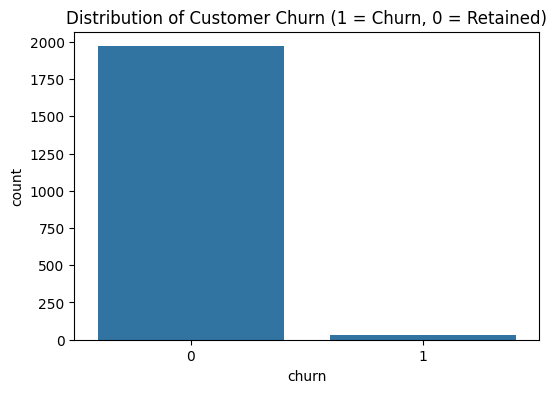

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import os

# ==========================================
# Task 1: Dataset Understanding
# ==========================================
print("Loading dataset...")
df = pd.read_csv(r'C:\Users\Vivek Vishwakarma\Documents\BA w AI\0B_Assignments\Assignment 5\ai_project_synthetic_datasets\part_1_neural_network_analysis\customer_churn_nn.csv')

print("--- Basic Exploration ---")
print(f"Shape: {df.shape}")
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe())

# Target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df)
plt.title('Distribution of Customer Churn (1 = Churn, 0 = Retained)')
plt.show()

In [ ]:
# ==========================================
# Task 2: Data Preprocessing
# ==========================================
print("\nStarting Data Preprocessing...")

# 1. Handling missing values
# Drop customer_id as it has no predictive value
df = df.drop(columns=['customer_id'])

# Separate features (X) and target (y)
X = df.drop(columns=['churn'])
y = df['churn']

# 2.Encode Categorical Columns
# This converts columns like 'region' into multiple 0/1 columns (e.g., region_North, region_South)
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 3. Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4.Scaling or normalizing numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Preprocessing complete. Input feature shape: {X_train_scaled.shape[1]} features.")


Starting Data Preprocessing...
Preprocessing complete. Input feature shape: 24 features.


In [7]:
# ==========================================
# Task 3: Neural Network Model Building
# ==========================================
def build_model(hidden_layers=1, neurons=32, learning_rate=0.001, activation='relu'):
    model = Sequential()
    
    # Input layer + First Hidden Layer
    model.add(Dense(neurons, input_shape=(X_train_scaled.shape[1],), activation=activation))
    
    # Additional hidden layers
    for _ in range(hidden_layers - 1):
        model.add(Dense(neurons, activation=activation))
        
    # Output layer for Binary Classification
    model.add(Dense(1, activation='sigmoid'))
    
    # Compiled model
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    return model


Training Baseline Model...


c:\Users\Vivek Vishwakarma\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Baseline Test Accuracy: 0.9825
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


FileNotFoundError: [Errno 2] No such file or directory: 'results/evaluation_outputs.png'

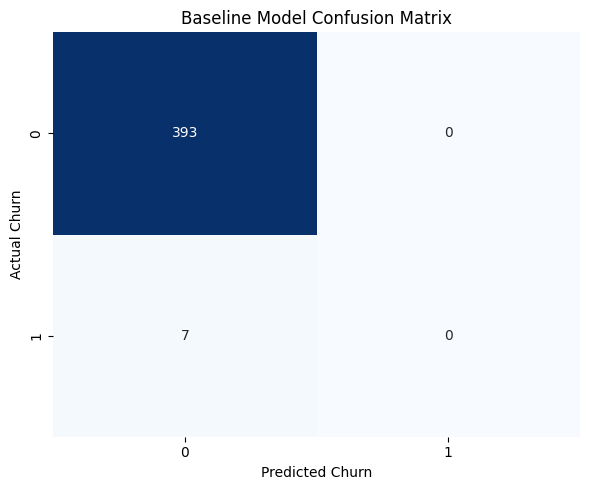

In [8]:
# ==========================================
# Task 4: Training and Evaluation (Baseline)
# ==========================================
print("\nTraining Baseline Model...")
baseline_model = build_model()
history = baseline_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Evaluate on Test Data
loss, accuracy = baseline_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Baseline Test Accuracy: {accuracy:.4f}")

# Generate Predictions for Confusion Matrix
y_pred_probs = baseline_model.predict(X_test_scaled)
y_pred = (y_pred_probs > 0.5).astype("int32")

# Confusion Matrix Plot
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Baseline Model Confusion Matrix')
plt.ylabel('Actual Churn')
plt.xlabel('Predicted Churn')
plt.tight_layout()
plt.savefig('results/evaluation_outputs.png') # Saving to results folder as requested
plt.show()